In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("mouse_viral_study (1).csv")

In [3]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

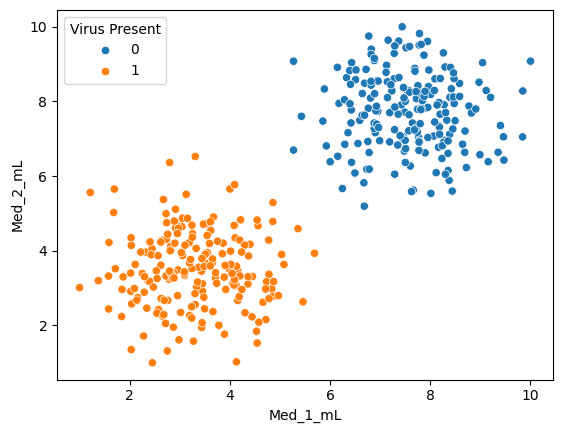

In [4]:
sns.scatterplot(x = "Med_1_mL",y = "Med_2_mL", hue = "Virus Present", data = df)

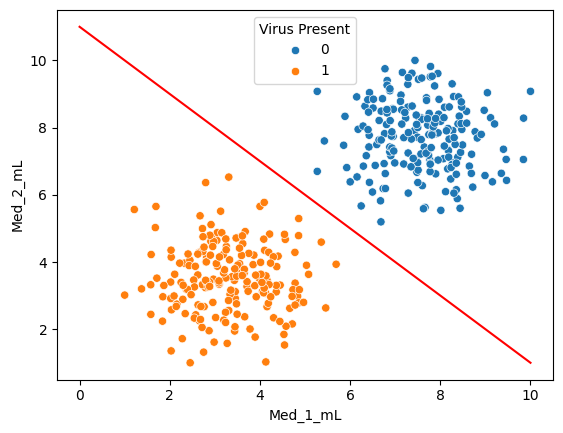

In [5]:
sns.scatterplot(x = "Med_1_mL",y = "Med_2_mL", hue = "Virus Present", data = df) 
# make a ref line 
x = np.linspace(0,10,100)
m = -1 
b = 11

y = m*x + b 
plt.plot(x,y,"r")

###  Support Vector Machines

In [6]:
from sklearn.svm import SVC  # support vector classifier 

In [7]:
#help(SVC)

In [8]:
X = df.drop("Virus Present", axis = 1)
y= df["Virus Present"]

In [9]:
model = SVC(kernel="linear", C = 0.1)
model.fit(X,y)

SVC(C=0.1, kernel='linear')

* C is inversely prop to number of proints allowed inside the soft region 

In [10]:
from svm_margin_plot import plot_svm_boundary


/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


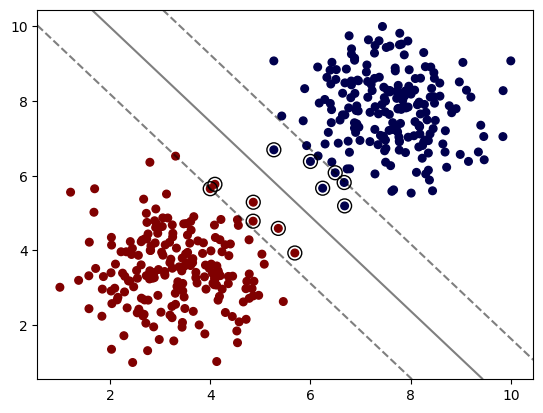

In [11]:
plot_svm_boundary(model, X,y)

### RBF (Radial Basis Function) kernel

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


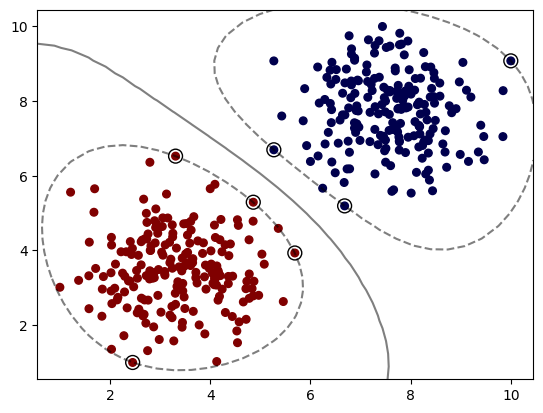

In [12]:
model = SVC(kernel="rbf", C = 10)
model.fit(X,y)
plot_svm_boundary(model, X, y)

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


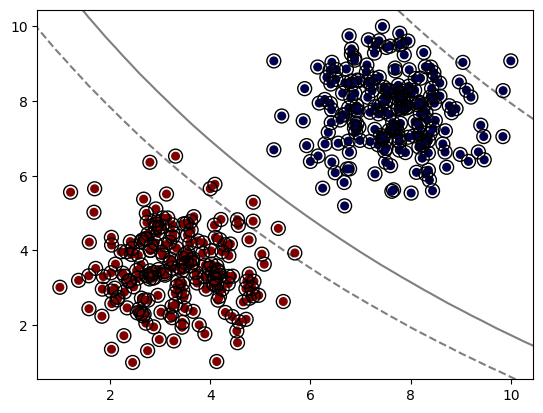

In [13]:
model = SVC(kernel="sigmoid", C = 1)
model.fit(X,y)
plot_svm_boundary(model, X, y)

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


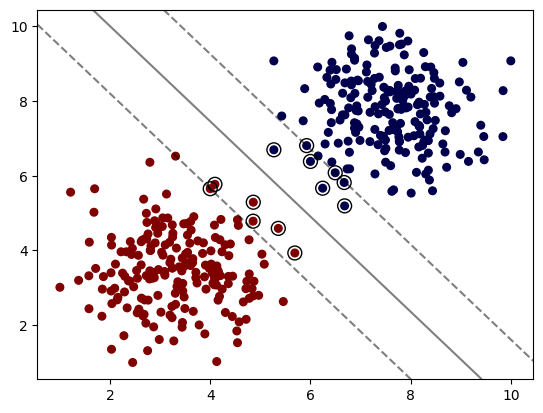

In [14]:
model = SVC(kernel="poly", C = 1, degree=1) # deg = 1 equal to linear 
model.fit(X,y)
plot_svm_boundary(model, X, y)

#### gamma

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


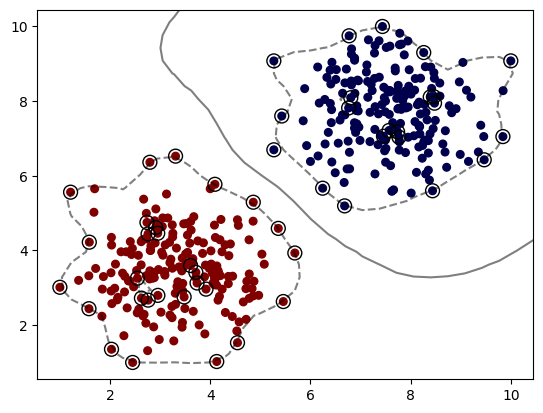

In [19]:
model = SVC(kernel="rbf", C = 1, degree=1, gamma=0.6) # deg = 1 equal to linear 
model.fit(X,y)
plot_svm_boundary(model, X, y)

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


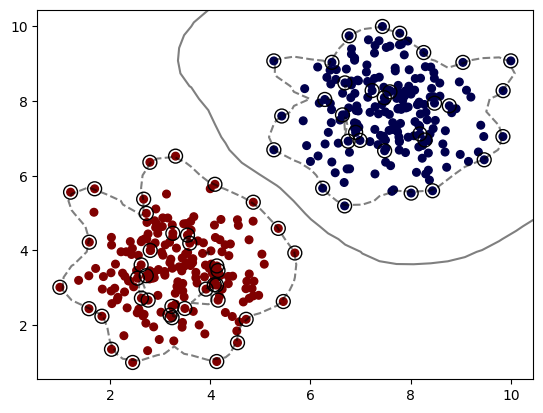

In [20]:
model = SVC(kernel="rbf", C = 1, degree=1, gamma=0.9) # deg = 1 equal to linear 
model.fit(X,y)
plot_svm_boundary(model, X, y)

#### Grid Search

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
svc = SVC()
param_grid = {'C':[0.01,0.1,1],
            'kernel':['linear','rbf']}
grid = GridSearchCV(svc, param_grid)

In [23]:
grid.fit(X,y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']})

In [24]:
grid.best_score_


1.0

In [25]:
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}